## 1. Package Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import random

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

onefig_size = (10, 4)
multifigs_size = (14, 5)

## 2. Dataset Overview

Dataset bao gồm hơn 1 triệu bản ghi nhập viện tại các bệnh viện bang New York năm 2009, với 11 biến:

* `Service Area`: Khu vực dịch vụ y tế (New York City, Long Island, Hudson Valley,...)
* `County`: Quận nơi bệnh viện đặt trụ sở
* `Name`: Tên bệnh viện
* `Age Group`: Nhóm tuổi bệnh nhân (0-17, 18-29, 30-49, 50-69, 70+)
* `Gender`: Giới tính (M: Nam, F: Nữ, U: Không xác định)
* `Race`: Chủng tộc
* `Ethnicity`: Dân tộc (Hispanic/Non-Hispanic)
* `Length of Stay`: Số ngày nằm viện
* `Admission Type`: Loại nhập viện (Elective, Emergency, Urgent, Trauma, Newborn)
* `Discharge Year`: Năm xuất viện (2009)
* `Total Charges`: **Chi phí nhập viện (biến mục tiêu cần dự đoán)**

In [2]:
original_df = pd.read_csv('NY Hospital Admissions - Dataset.csv')
original_df.head(10)

,Service Area,County,Name,Age Group,Gender,Race,Ethnicity,Length of Stay,Admission Type,Discharge Year,Total Charges
0,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2.0,Elective,2009,11424.60
1,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,1.0,Elective,2009,19040.55
2,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2.0,Emergency,2009,20700.66
3,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2.0,Elective,2009,12807.24
4,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2.0,Elective,2009,32185.88
5,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2.0,Elective,2009,20831.68
6,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,3.0,Elective,2009,17670.10
7,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,4.0,Emergency,2009,29514.61
8,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,5.0,Emergency,2009,25147.73
9,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,7.0,Elective,2009,40091.22


In [3]:
print(f"Dataset có {original_df.shape[0]:,} dòng và {original_df.shape[1]} cột")
print(f"Số bệnh viện: {original_df['Name'].nunique()}")

Dataset có 1,048,575 dòng và 11 cột
Số bệnh viện: 224


In [4]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Service Area    1046524 non-null  object 
 1   County          1046524 non-null  object 
 2   Name            1048575 non-null  object 
 3   Age Group       1048575 non-null  object 
 4   Gender          1048575 non-null  object 
 5   Race            1048575 non-null  object 
 6   Ethnicity       1048575 non-null  object 
 7   Length of Stay  1047784 non-null  float64
 8   Admission Type  1048575 non-null  object 
 9   Discharge Year  1048575 non-null  int64  
 10  Total Charges   1048575 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 88.0+ MB


Xem các giá trị duy nhất của các biến categorical:

In [5]:
categorical_cols = ['Service Area', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Admission Type']
for col in categorical_cols:
    print(f"{col}: {original_df[col].unique()}")
    print()

Service Area: ['New York City' 'Long Island' nan 'Hudson Valley' 'Capital/Adiron'
 'Finger Lakes' 'Southern Tier' 'Western NY' 'Central NY']

Age Group: ['30 to 49' '50 to 69' '70 or Older' '0 to 17' '18 to 29']

Gender: ['F' 'M' 'U']

Race: ['White' 'Black/African American' 'Other Race' 'Unknown']

Ethnicity: ['Not Span/Hispanic' 'Unknown' 'Spanish/Hispanic']

Admission Type: ['Elective' 'Emergency' 'Urgent' 'Not Available' 'Trauma' 'Newborn']



Thống kê mô tả các biến số:

In [6]:
original_df.describe()

,Length of Stay,Discharge Year,Total Charges
count,1.047784e+06,1048575.0,1.048575e+06
mean,5.374921e+00,2009.0,2.961692e+04
std,7.475378e+00,0.0,5.425011e+04
min,1.000000e+00,2009.0,1.000000e+00
25%,2.000000e+00,2009.0,7.900000e+03
50%,3.000000e+00,2009.0,1.590541e+04
75%,6.000000e+00,2009.0,3.228415e+04
max,1.190000e+02,2009.0,4.095733e+06


**Nhận xét:**
* `Length of Stay` (số ngày nằm viện): từ 1 đến 119 ngày, trung bình ~5.4 ngày
* `Total Charges` (chi phí): từ \$1 đến hơn \$4 triệu, trung bình ~\$29,617, median ~\$15,905

## 3. Data Integration

Dataset được lấy từ một nguồn duy nhất (NY State Department of Health), do đó không cần tích hợp dữ liệu từ nhiều nguồn khác nhau.

## 4. Data Cleaning

In [7]:
df = original_df.copy()

### 4.1. Data Duplication

In [8]:
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates:,}")
print(f"Tỷ lệ: {duplicates/len(df)*100:.2f}%")

Số dòng trùng lặp: 63,071
Tỷ lệ: 6.01%


In [9]:
# Xóa các dòng trùng lặp
df = df.drop_duplicates()
print(f"Sau khi xóa trùng lặp: {len(df):,} dòng")

Sau khi xóa trùng lặp: 985,504 dòng


### 4.2. Missing Data

In [10]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing %': missing_percent})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
Service Area,2009,0.20
County,2009,0.20
Length of Stay,791,0.08


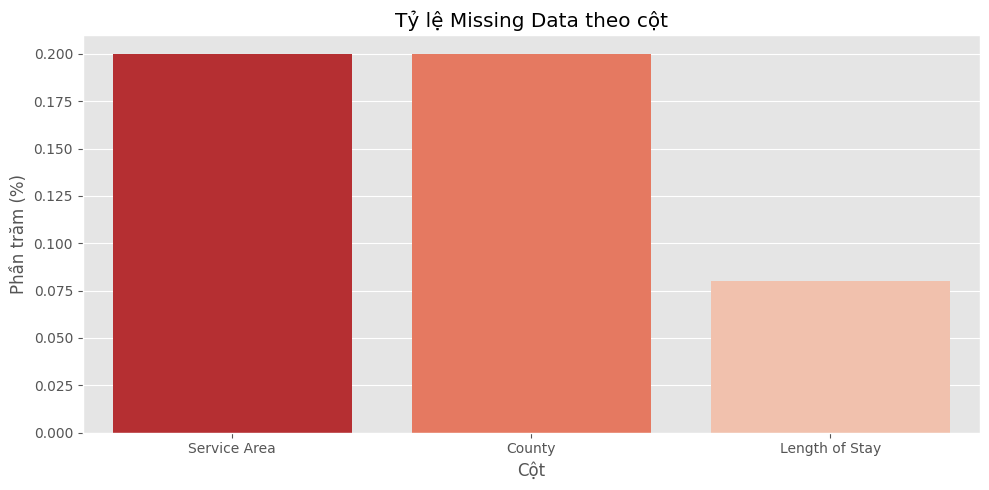

In [11]:
# Visualize missing data
plt.figure(figsize=(10, 5))
missing_cols = missing_df[missing_df['Missing Count'] > 0].index
sns.barplot(x=missing_cols, y=missing_df.loc[missing_cols, 'Missing %'], palette='Reds_r')
plt.title('Tỷ lệ Missing Data theo cột')
plt.ylabel('Phần trăm (%)')
plt.xlabel('Cột')
plt.tight_layout()
plt.show()

**Xử lý Missing Data:**
- `Service Area` và `County`: Có thể suy luận từ `Name` (tên bệnh viện) hoặc xóa
- `Length of Stay`: Xóa các dòng thiếu vì đây là biến quan trọng

In [12]:
# Xóa các dòng có missing values
df_clean = df.dropna()
print(f"Trước khi xóa missing: {len(df):,} dòng")
print(f"Sau khi xóa missing: {len(df_clean):,} dòng")
print(f"Số dòng bị xóa: {len(df) - len(df_clean):,}")

Trước khi xóa missing: 985,504 dòng
Sau khi xóa missing: 982,705 dòng
Số dòng bị xóa: 2,799


In [13]:
df = df_clean.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 982705 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Service Area    982705 non-null  object 
 1   County          982705 non-null  object 
 2   Name            982705 non-null  object 
 3   Age Group       982705 non-null  object 
 4   Gender          982705 non-null  object 
 5   Race            982705 non-null  object 
 6   Ethnicity       982705 non-null  object 
 7   Length of Stay  982705 non-null  float64
 8   Admission Type  982705 non-null  object 
 9   Discharge Year  982705 non-null  int64  
 10  Total Charges   982705 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 90.0+ MB


### 4.3. Data Type Conversion

In [14]:
# Chuyển đổi kiểu dữ liệu cho các biến categorical
categorical_cols = ['Service Area', 'County', 'Name', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Admission Type']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Length of Stay nên là integer
df['Length of Stay'] = df['Length of Stay'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 982705 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Service Area    982705 non-null  category
 1   County          982705 non-null  category
 2   Name            982705 non-null  category
 3   Age Group       982705 non-null  category
 4   Gender          982705 non-null  category
 5   Race            982705 non-null  category
 6   Ethnicity       982705 non-null  category
 7   Length of Stay  982705 non-null  int64   
 8   Admission Type  982705 non-null  category
 9   Discharge Year  982705 non-null  int64   
 10  Total Charges   982705 non-null  float64 
dtypes: category(8), float64(1), int64(2)
memory usage: 38.4 MB


### 4.4. Outliers Detection

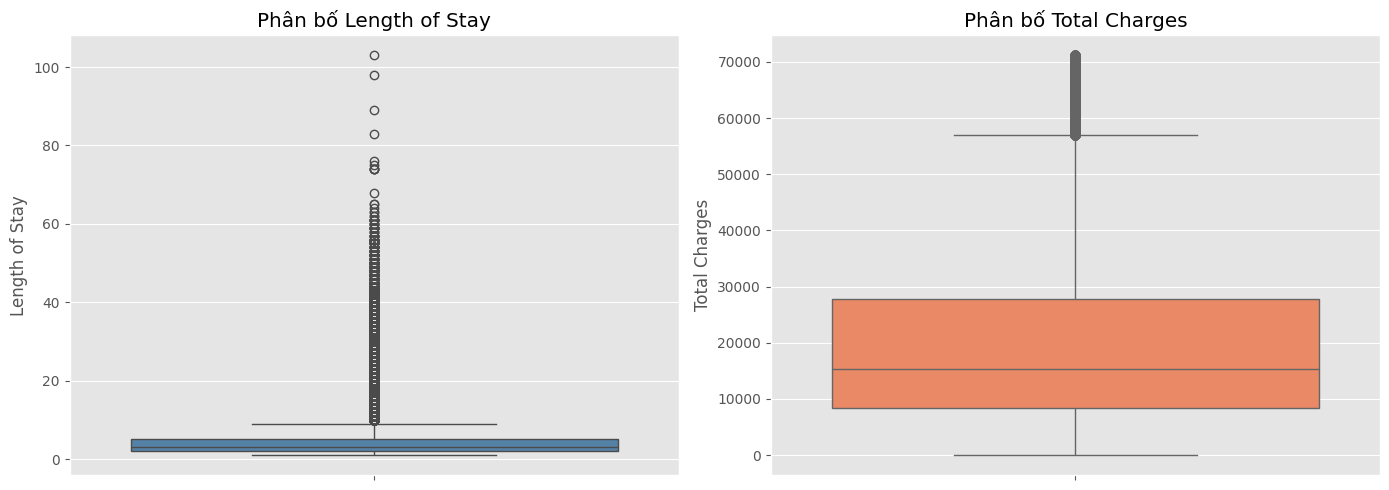

In [63]:
fig, axes = plt.subplots(1, 2, figsize=multifigs_size)

sns.boxplot(data=df, y='Length of Stay', ax=axes[0], color='steelblue')
axes[0].set_title('Phân bố Length of Stay')

sns.boxplot(data=df, y='Total Charges', ax=axes[1], color='coral')
axes[1].set_title('Phân bố Total Charges')

plt.tight_layout()
plt.show()

In [16]:
# Xử lý outliers bằng IQR method cho Total Charges
Q1 = df['Total Charges'].quantile(0.25)
Q3 = df['Total Charges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Total Charges'] < lower_bound) | (df['Total Charges'] > upper_bound)]
print(f"Số outliers trong Total Charges: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

Số outliers trong Total Charges: 83,343 (8.48%)
Lower bound: $-28,459.00
Upper bound: $71,181.00


In [17]:
# Giữ lại dữ liệu trong khoảng hợp lệ (loại bỏ extreme outliers)
df = df[(df['Total Charges'] >= lower_bound) & (df['Total Charges'] <= upper_bound)]
print(f"Sau khi xử lý outliers: {len(df):,} dòng")

Sau khi xử lý outliers: 899,362 dòng


## 5. Exploratory Data Analysis (EDA)

In [18]:
print(f"Dataset sau khi làm sạch: {len(df):,} dòng")
df.describe()

Dataset sau khi làm sạch: 899,362 dòng


,Length of Stay,Discharge Year,Total Charges
count,899362.000000,899362.0,899362.000000
mean,4.289600,2009.0,20176.427287
std,4.128785,0.0,15601.100040
min,1.000000,2009.0,1.000000
25%,2.000000,2009.0,8327.000000
50%,3.000000,2009.0,15368.240000
75%,5.000000,2009.0,27820.395000
max,103.000000,2009.0,71181.000000


### 5.1. Prediction Variable (Total Charges)

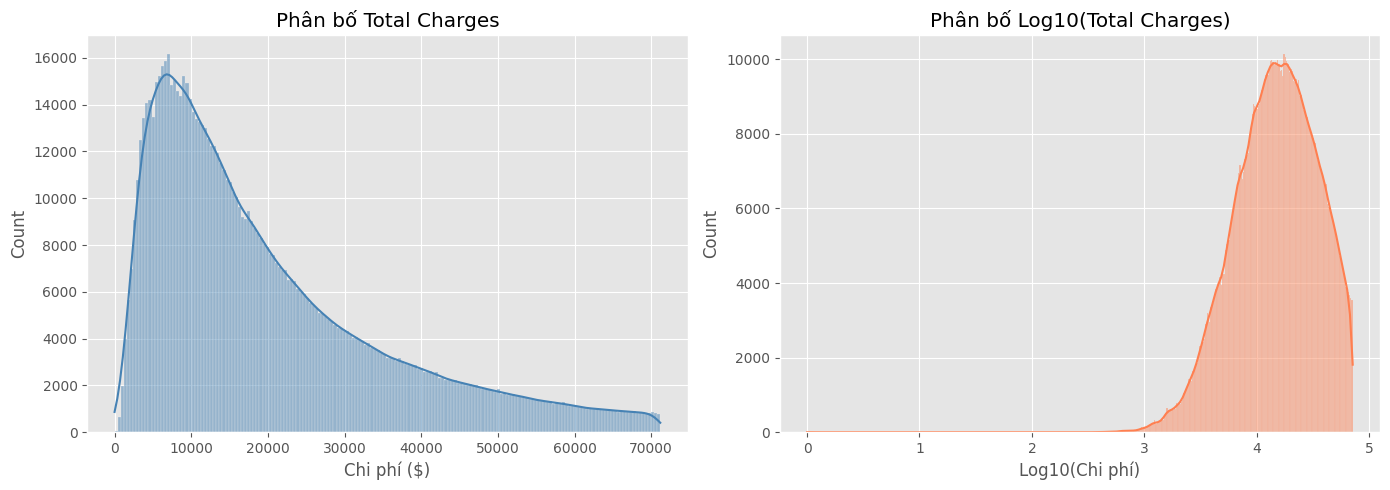

In [19]:
fig, axes = plt.subplots(1, 2, figsize=multifigs_size)

sns.histplot(df['Total Charges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Phân bố Total Charges')
axes[0].set_xlabel('Chi phí ($)')

sns.histplot(np.log10(df['Total Charges']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Phân bố Log10(Total Charges)')
axes[1].set_xlabel('Log10(Chi phí)')

plt.tight_layout()
plt.show()

**Nhận xét:** Phân bố `Total Charges` lệch phải (right-skewed). Sau khi áp dụng log transformation, phân bố gần với phân phối chuẩn hơn.

### 5.2. Categorical Variables

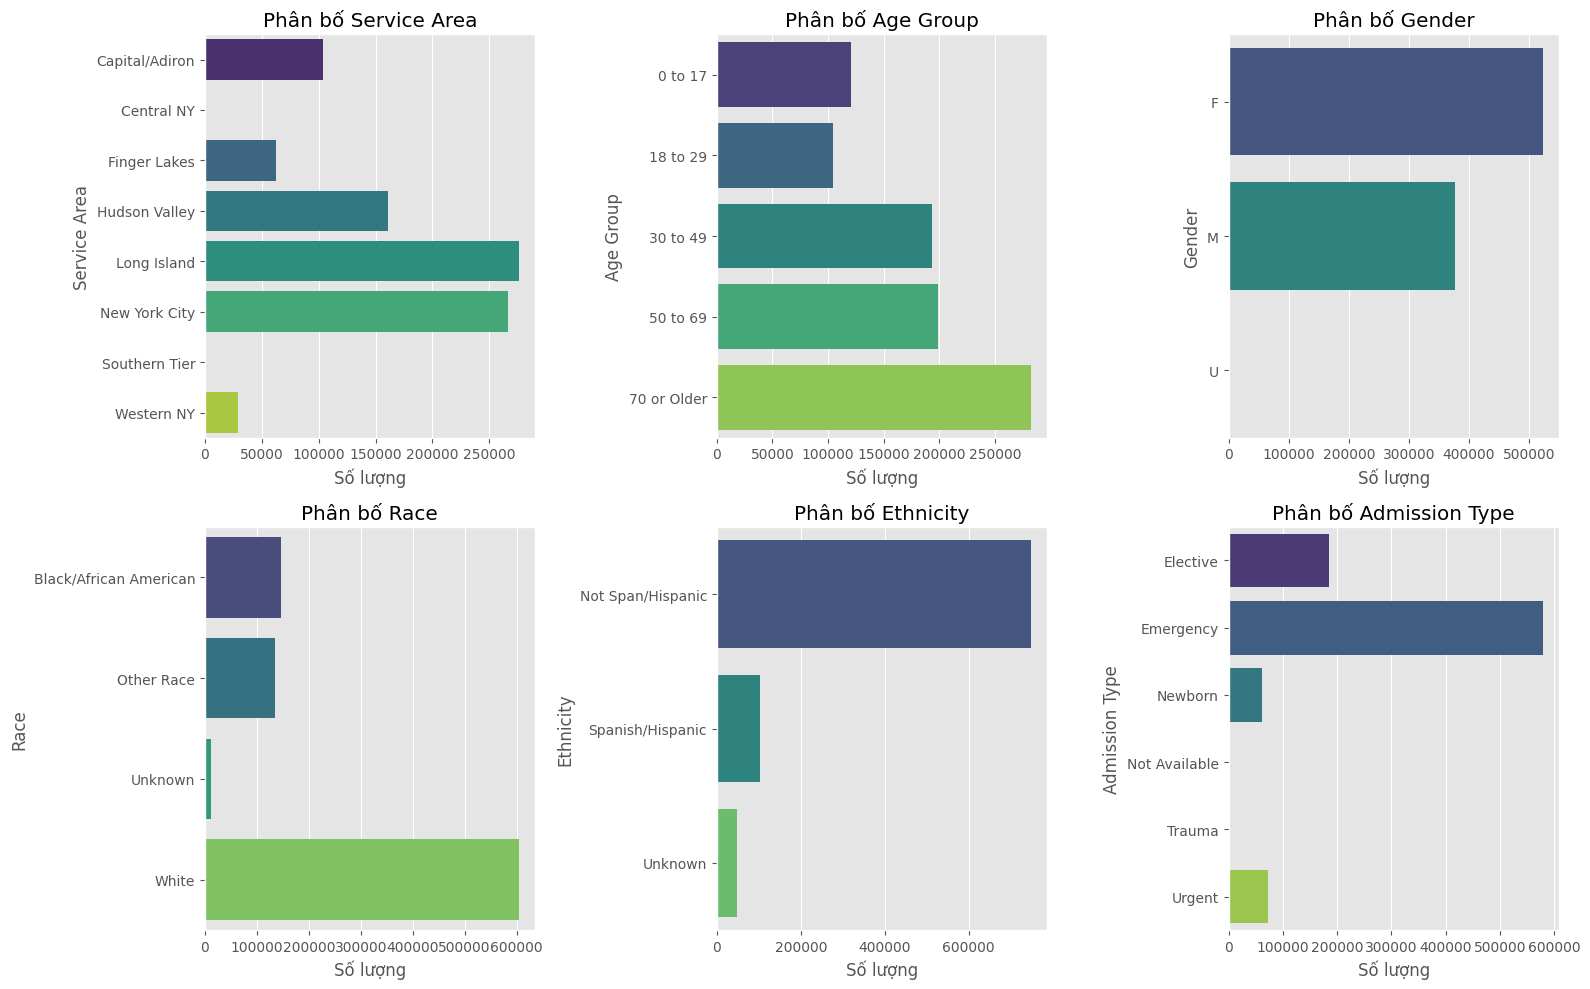

In [20]:
cat_cols = ['Service Area', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Admission Type']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Phân bố {col}')
    axes[i].set_xlabel('Số lượng')

plt.tight_layout()
plt.show()

In [21]:
# Thống kê tần suất
for col in cat_cols:
    print(f"=== {col} ===")
    freq = df[col].value_counts()
    freq_df = pd.DataFrame({'Count': freq, 'Percent': (freq/len(df)*100).round(2)})
    print(freq_df)
    print()

=== Service Area ===
                 Count  Percent
Service Area                   
Long Island     276182    30.71
New York City   266040    29.58
Hudson Valley   160781    17.88
Capital/Adiron  103604    11.52
Finger Lakes     62409     6.94
Western NY       29388     3.27
Southern Tier      818     0.09
Central NY         140     0.02

=== Age Group ===
              Count  Percent
Age Group                   
70 or Older  282281    31.39
50 to 69     199126    22.14
30 to 49     193300    21.49
0 to 17      120594    13.41
18 to 29     104061    11.57

=== Gender ===
         Count  Percent
Gender                 
F       523026    58.16
M       376321    41.84
U           15     0.00

=== Race ===
                         Count  Percent
Race                                   
White                   604749    67.24
Black/African American  147238    16.37
Other Race              135438    15.06
Unknown                  11937     1.33

=== Ethnicity ===
                    Count  P

**Nhận xét:**
- `Service Area`: New York City chiếm đa số
- `Age Group`: Nhóm 50-69 và 70+ chiếm tỷ lệ cao nhất
- `Gender`: Nữ nhiều hơn Nam một chút
- `Admission Type`: Emergency chiếm đa số, sau đó là Elective

#### Chi phí theo từng biến categorical

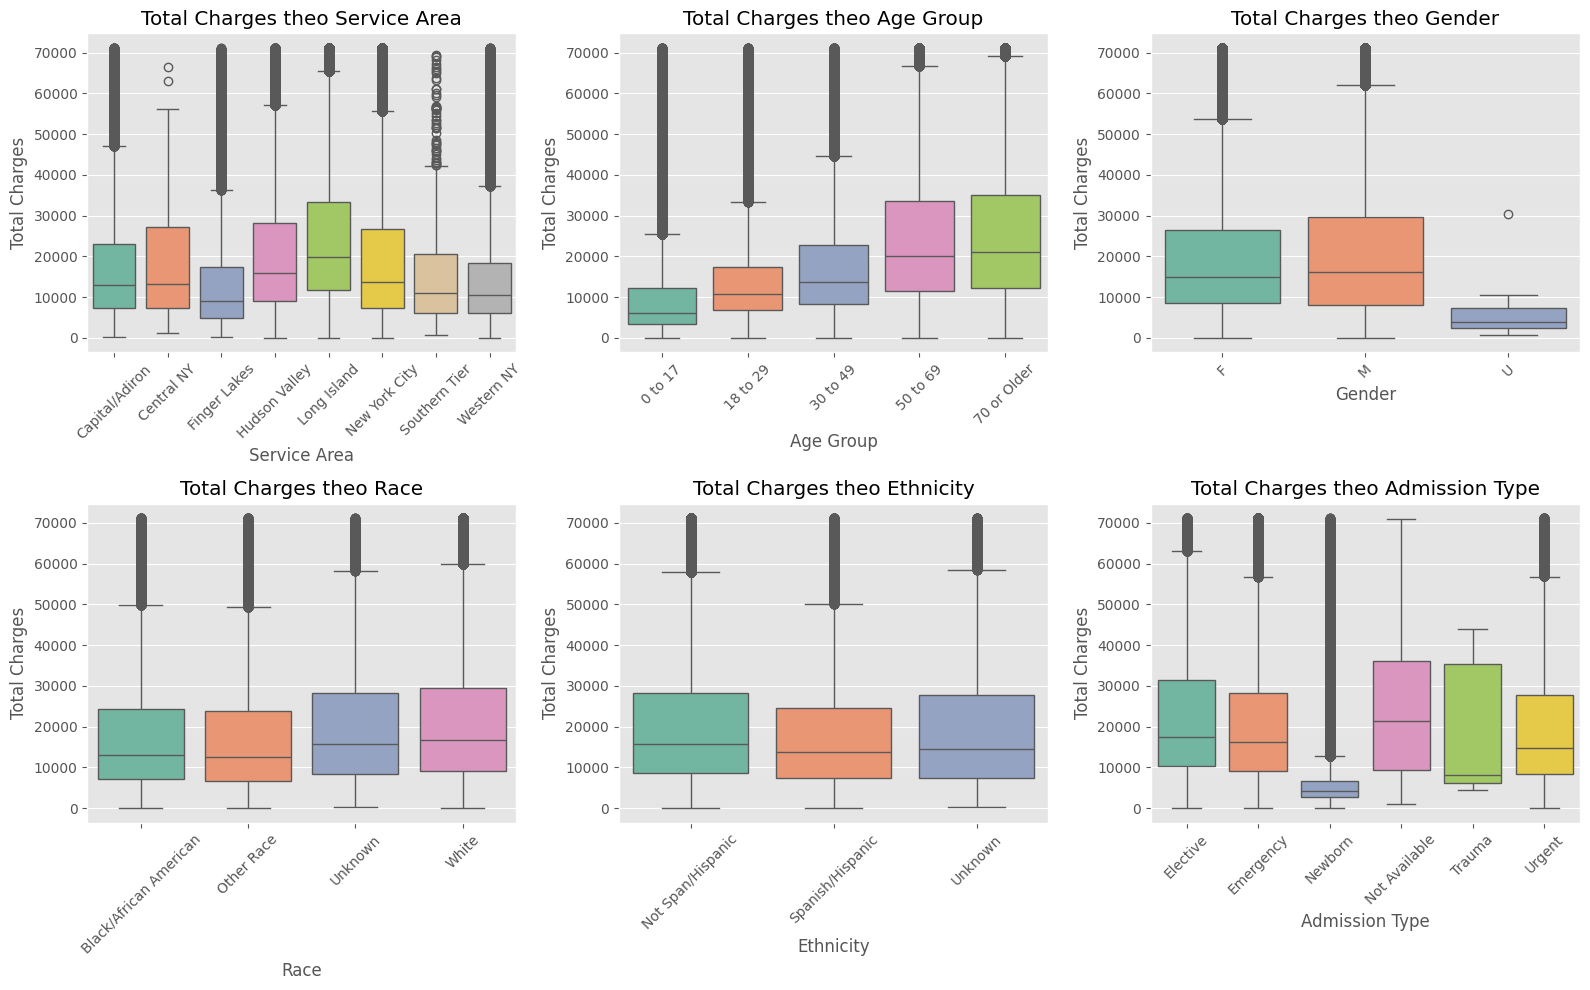

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='Total Charges', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Total Charges theo {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

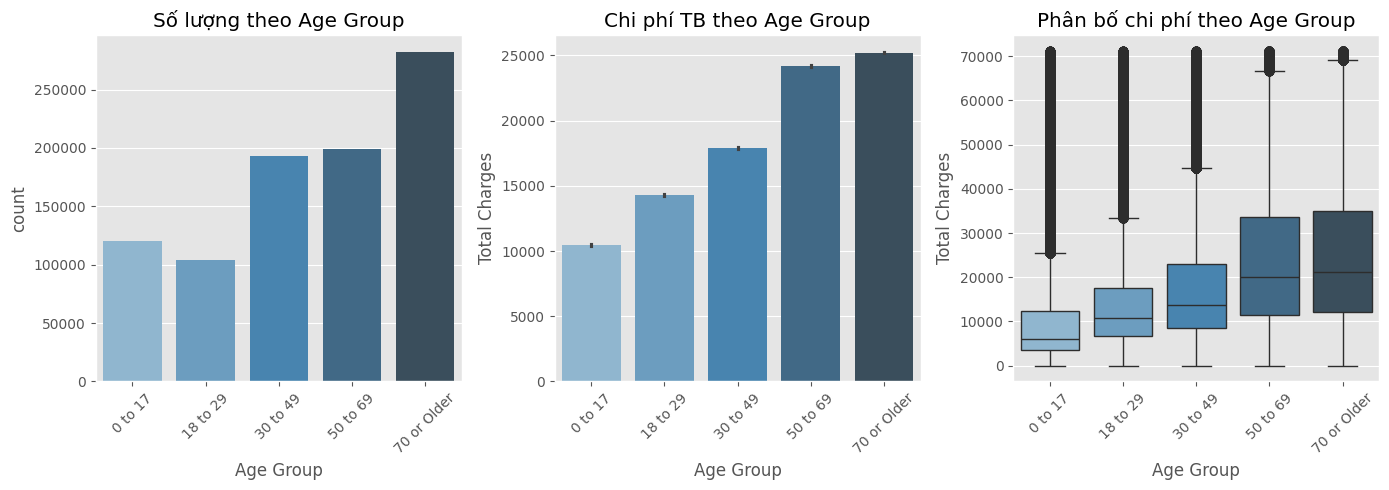

In [23]:
# Chi phí trung bình theo Age Group
fig, axes = plt.subplots(1, 3, figsize=multifigs_size)

sns.countplot(data=df, x='Age Group', ax=axes[0], palette='Blues_d')
axes[0].set_title('Số lượng theo Age Group')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='Age Group', y='Total Charges', ax=axes[1], palette='Blues_d')
axes[1].set_title('Chi phí TB theo Age Group')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Age Group', y='Total Charges', ax=axes[2], palette='Blues_d')
axes[2].set_title('Phân bố chi phí theo Age Group')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

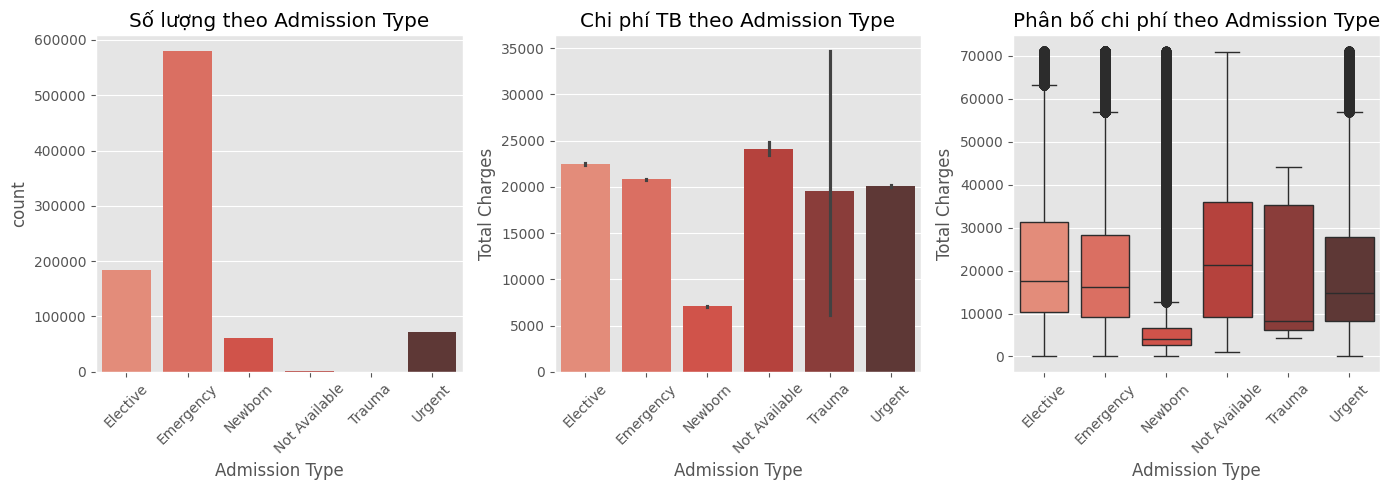

In [24]:
# Chi phí theo Admission Type
fig, axes = plt.subplots(1, 3, figsize=multifigs_size)

sns.countplot(data=df, x='Admission Type', ax=axes[0], palette='Reds_d')
axes[0].set_title('Số lượng theo Admission Type')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='Admission Type', y='Total Charges', ax=axes[1], palette='Reds_d')
axes[1].set_title('Chi phí TB theo Admission Type')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Admission Type', y='Total Charges', ax=axes[2], palette='Reds_d')
axes[2].set_title('Phân bố chi phí theo Admission Type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

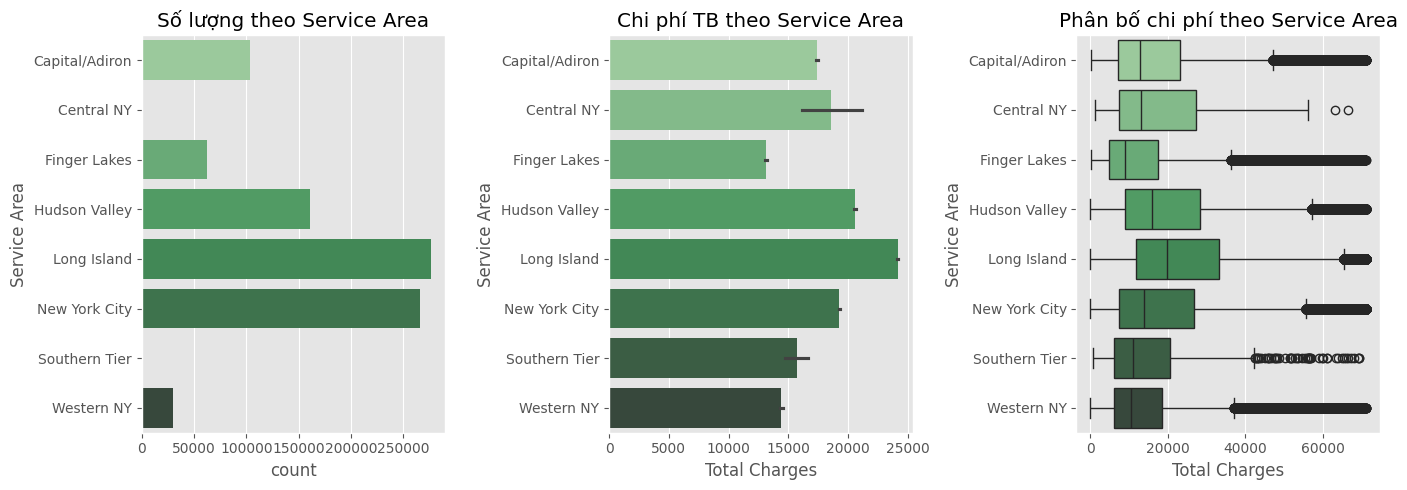

In [25]:
# Chi phí theo Service Area
fig, axes = plt.subplots(1, 3, figsize=multifigs_size)

sns.countplot(data=df, y='Service Area', ax=axes[0], palette='Greens_d')
axes[0].set_title('Số lượng theo Service Area')

sns.barplot(data=df, y='Service Area', x='Total Charges', ax=axes[1], palette='Greens_d')
axes[1].set_title('Chi phí TB theo Service Area')

sns.boxplot(data=df, y='Service Area', x='Total Charges', ax=axes[2], palette='Greens_d')
axes[2].set_title('Phân bố chi phí theo Service Area')

plt.tight_layout()
plt.show()

### 5.3. Data Visualization

#### 5.3.1. Correlation Matrix

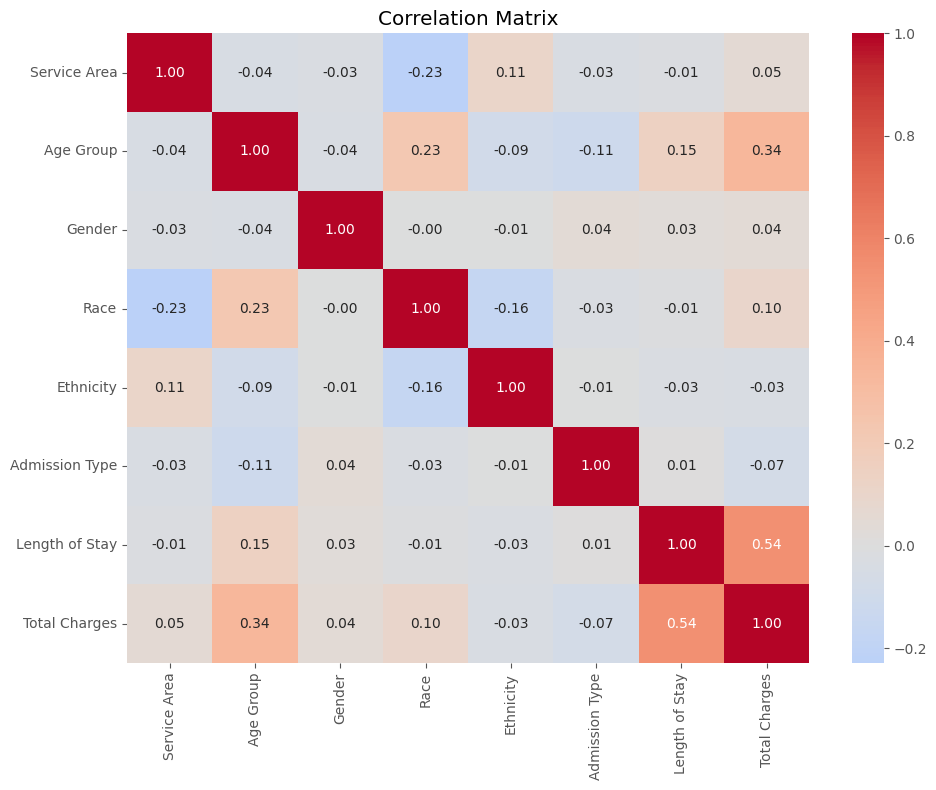

In [26]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Encode categorical variables
label_encoder = LabelEncoder()
encode_cols = ['Service Area', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Admission Type']

for col in encode_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col].astype(str))

# Chọn các cột số để tính correlation
numeric_cols = ['Service Area', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Admission Type', 'Length of Stay', 'Total Charges']
corr_matrix = df_encoded[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Nhận xét:** `Length of Stay` có tương quan mạnh nhất với `Total Charges`. Điều này hợp lý vì nằm viện càng lâu thì chi phí càng cao.

#### 5.3.2. Length of Stay vs Total Charges

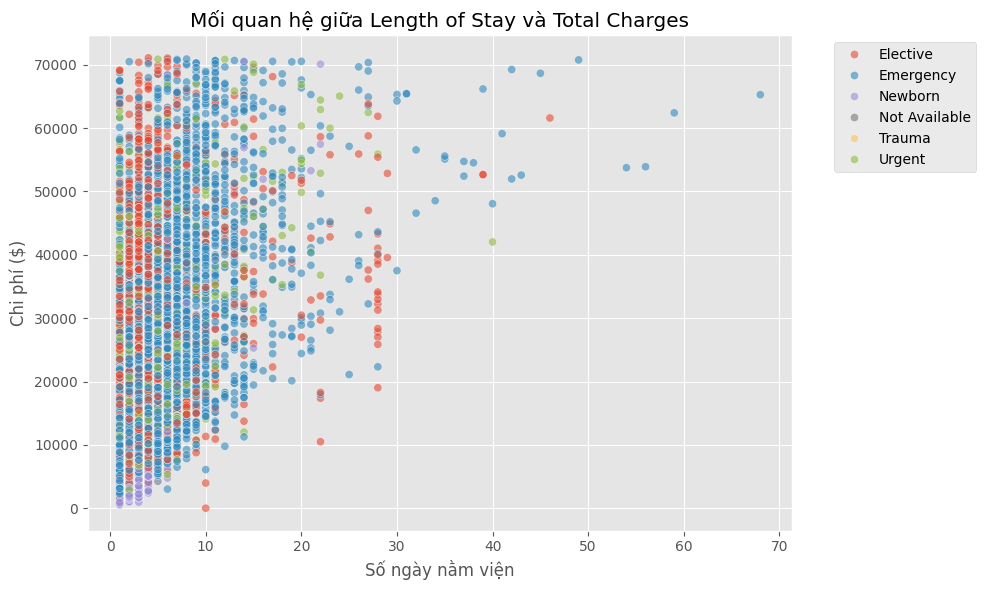

In [27]:
# Sample data để vẽ (do dataset quá lớn)
df_sample = df.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='Length of Stay', y='Total Charges', hue='Admission Type', alpha=0.6)
plt.title('Mối quan hệ giữa Length of Stay và Total Charges')
plt.xlabel('Số ngày nằm viện')
plt.ylabel('Chi phí ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

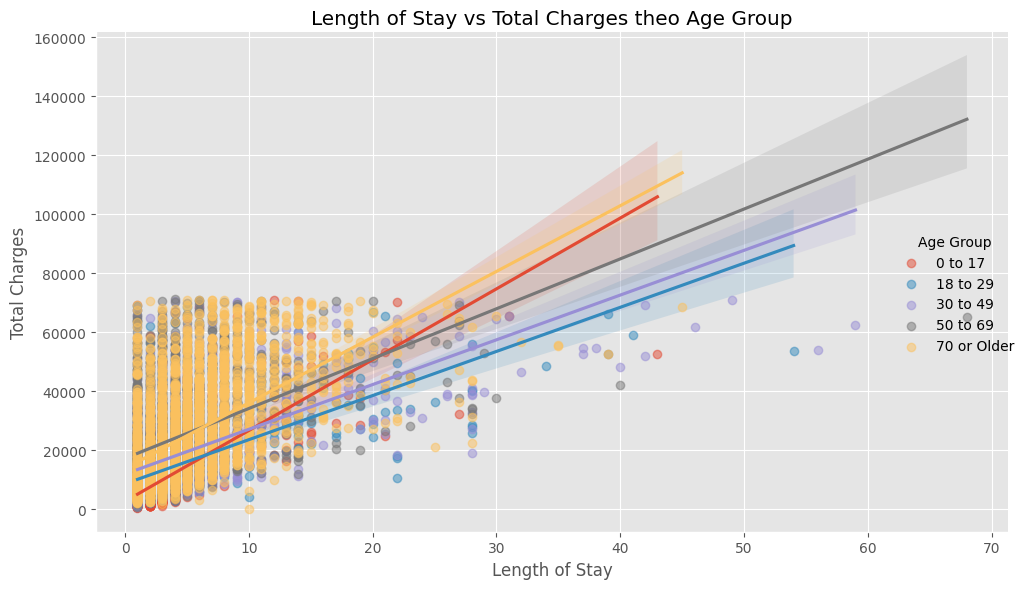

In [28]:
sns.lmplot(data=df_sample, x='Length of Stay', y='Total Charges', hue='Age Group', 
           height=6, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title('Length of Stay vs Total Charges theo Age Group')
plt.tight_layout()
plt.show()

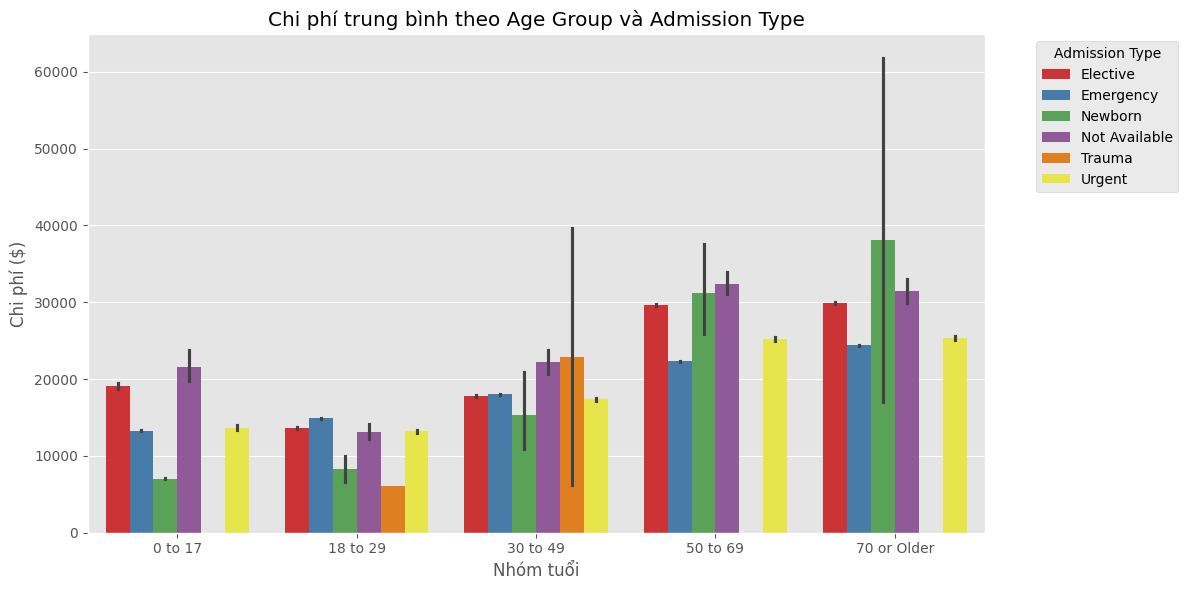

In [29]:
# Chi phí theo Age Group và Admission Type
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Age Group', y='Total Charges', hue='Admission Type', palette='Set1')
plt.title('Chi phí trung bình theo Age Group và Admission Type')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Chi phí ($)')
plt.legend(title='Admission Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

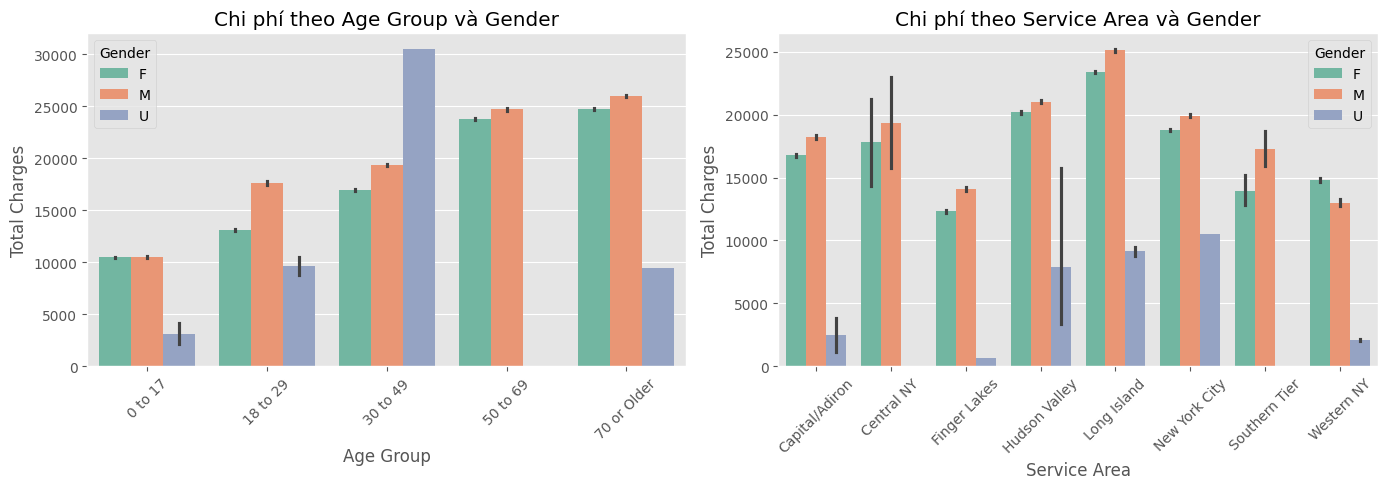

In [30]:
# Chi phí theo Gender và Age Group
fig, axes = plt.subplots(1, 2, figsize=multifigs_size)

sns.barplot(data=df, x='Age Group', y='Total Charges', hue='Gender', ax=axes[0], palette='Set2')
axes[0].set_title('Chi phí theo Age Group và Gender')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='Service Area', y='Total Charges', hue='Gender', ax=axes[1], palette='Set2')
axes[1].set_title('Chi phí theo Service Area và Gender')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 5.3.3. Top Hospitals by Charges

In [61]:
# Top 15 bệnh viện có chi phí trung bình cao nhất
top_hospitals = df.groupby('Name')['Total Charges'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False).head(15)
top_hospitals.columns = ['Chi phí TB ($)', 'Số ca nhập viện', 'Độ lệch chuẩn ($)']
top_hospitals['Chi phí TB ($)'] = top_hospitals['Chi phí TB ($)'].apply(lambda x: f"${x:,.2f}")
top_hospitals['Độ lệch chuẩn ($)'] = top_hospitals['Độ lệch chuẩn ($)'].apply(lambda x: f"${x:,.2f}")
top_hospitals['Số ca nhập viện'] = top_hospitals['Số ca nhập viện'].apply(lambda x: f"{x:,}")
top_hospitals.index.name = 'Tên Bệnh viện'
top_hospitals.reset_index(inplace=True)
top_hospitals.index = range(1, 16)  # Đánh số từ 1-15
top_hospitals.index.name = 'Rank'

print("=" * 100)
print("TOP 15 BỆNH VIỆN CÓ CHI PHÍ NHẬP VIỆN TRUNG BÌNH CAO NHẤT (Bang New York, 2009)")
print("=" * 100)
display(top_hospitals)
print("=" * 100)

TOP 15 BỆNH VIỆN CÓ CHI PHÍ NHẬP VIỆN TRUNG BÌNH CAO NHẤT (Bang New York, 2009)


,Tên Bệnh viện,Chi phí TB ($),Số ca nhập viện,Độ lệch chuẩn ($)
Rank,,,,
1,Hospital for Special Surgery,"$43,653.65","3,585","$13,100.58"
2,Institute of Rehab Medicine NYU Medical Center,"$40,085.26",258,"$14,458.70"
3,NYU Hospital for Joint Diseases,"$39,084.44","1,190","$17,731.98"
4,Rockefeller University Hospital,"$38,846.50",3,"$15,310.56"
5,Blythedale Childrens Hospital,"$35,241.08",80,"$17,940.94"
6,St Francis Hospital,"$33,135.78","10,123","$17,910.95"
7,Chenango Memorial Hospital Inc,"$33,000.30",17,"$10,042.21"
8,Montefiore Medical Center - Henry & Lucy Moses...,"$30,800.20","14,127","$15,957.48"
9,Montefiore Medical Center - North Division,"$30,416.14","4,394","$16,682.84"


## 6. Feature Engineering

In [32]:
df_fe = df.copy()

### 6.1. Tạo biến Length of Stay Groups

In [33]:
def categorize_los(row):
    los = row['Length of Stay']
    if los <= 2:
        return 'Short (1-2 days)'
    elif los <= 5:
        return 'Medium (3-5 days)'
    elif los <= 10:
        return 'Long (6-10 days)'
    else:
        return 'Extended (>10 days)'

df_fe['LOS_Group'] = df_fe.apply(categorize_los, axis=1)
df_fe['LOS_Group'].value_counts()

LOS_Group
Short (1-2 days)       352028
Medium (3-5 days)      340279
Long (6-10 days)       149041
Extended (>10 days)     58014
Name: count, dtype: int64

### 6.2. Tạo biến Urgency Level

In [34]:
def categorize_urgency(row):
    admission = row['Admission Type']
    if admission in ['Emergency', 'Trauma']:
        return 'High Urgency'
    elif admission == 'Urgent':
        return 'Medium Urgency'
    else:  # Elective, Newborn, Not Available
        return 'Low Urgency'

df_fe['Urgency_Level'] = df_fe.apply(categorize_urgency, axis=1)
df_fe['Urgency_Level'].value_counts()

Urgency_Level
High Urgency      579269
Low Urgency       248397
Medium Urgency     71696
Name: count, dtype: int64

### 6.3. Tạo biến Age Risk

In [35]:
def categorize_age_risk(row):
    age = row['Age Group']
    if age in ['0 to 17', '70 or Older']:
        return 'High Risk Age'
    elif age in ['50 to 69']:
        return 'Medium Risk Age'
    else:  # 18-29, 30-49
        return 'Low Risk Age'

df_fe['Age_Risk'] = df_fe.apply(categorize_age_risk, axis=1)
df_fe['Age_Risk'].value_counts()

Age_Risk
High Risk Age      402875
Low Risk Age       297361
Medium Risk Age    199126
Name: count, dtype: int64

In [36]:
df_fe.head()

,Service Area,County,Name,Age Group,Gender,Race,Ethnicity,Length of Stay,Admission Type,Discharge Year,Total Charges,LOS_Group,Urgency_Level,Age_Risk
0,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2,Elective,2009,11424.60,Short (1-2 days),Low Urgency,Low Risk Age
1,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,1,Elective,2009,19040.55,Short (1-2 days),Low Urgency,Low Risk Age
2,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2,Emergency,2009,20700.66,Short (1-2 days),High Urgency,Low Risk Age
3,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2,Elective,2009,12807.24,Short (1-2 days),Low Urgency,Low Risk Age
4,New York City,Manhattan,Mount Sinai Hospital,30 to 49,F,White,Not Span/Hispanic,2,Elective,2009,32185.88,Short (1-2 days),Low Urgency,Low Risk Age


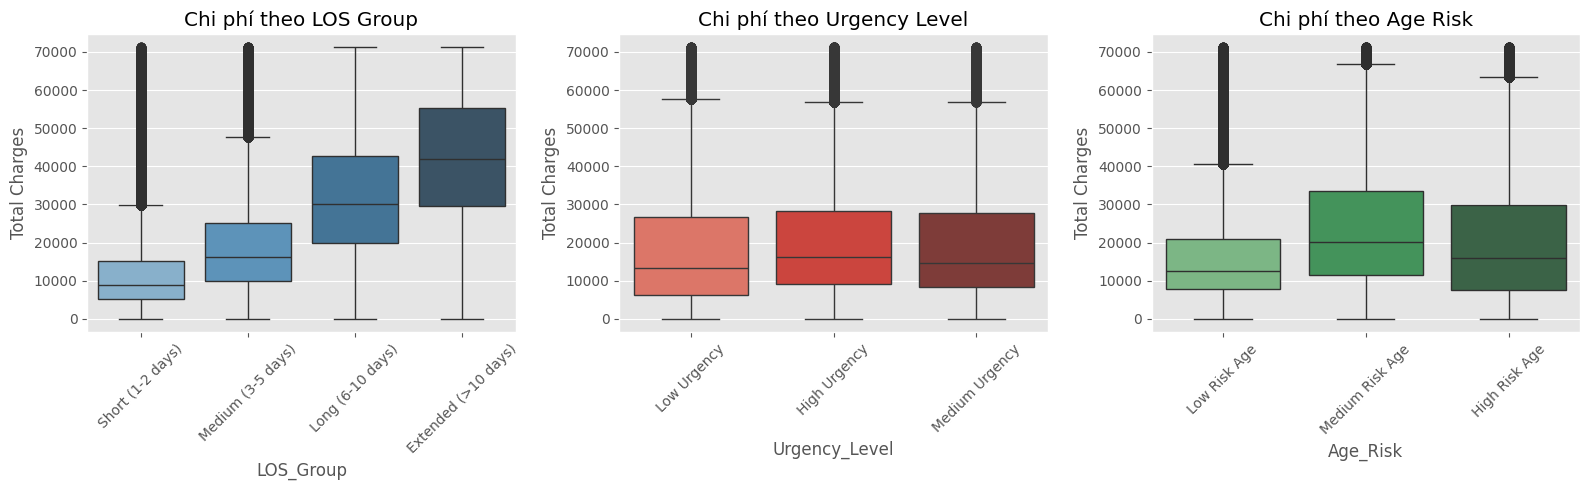

In [37]:
# Visualize các feature mới
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_fe, x='LOS_Group', y='Total Charges', ax=axes[0], palette='Blues_d')
axes[0].set_title('Chi phí theo LOS Group')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_fe, x='Urgency_Level', y='Total Charges', ax=axes[1], palette='Reds_d')
axes[1].set_title('Chi phí theo Urgency Level')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_fe, x='Age_Risk', y='Total Charges', ax=axes[2], palette='Greens_d')
axes[2].set_title('Chi phí theo Age Risk')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

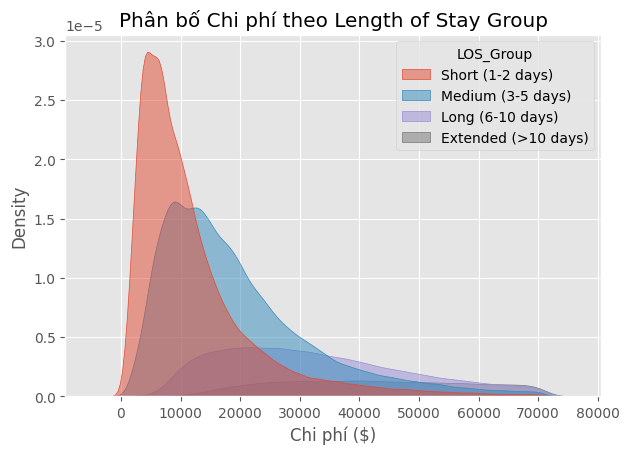

In [38]:
# Phân bố chi phí theo các nhóm đã tạo
sns.kdeplot(data=df_fe, x='Total Charges', hue='LOS_Group', fill=True, alpha=0.5)
plt.title('Phân bố Chi phí theo Length of Stay Group')
plt.xlabel('Chi phí ($)')
plt.tight_layout()
plt.show()

## 7. Experiment

### 7.1. Prepare Train Test Dataset

In [39]:
from sklearn.model_selection import train_test_split

# Sử dụng một sample để training (do dataset quá lớn)
df_model = df_fe.sample(n=100000, random_state=42).copy()

# Chuyển categorical thành category type
category_cols = ['Service Area', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Admission Type', 'LOS_Group', 'Urgency_Level', 'Age_Risk']
for col in category_cols:
    df_model[col] = df_model[col].astype('category')

# Loại bỏ các cột không cần thiết cho model
drop_cols = ['County', 'Name', 'Discharge Year']
df_model = df_model.drop(columns=drop_cols)

df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 824110 to 89709
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Service Area    100000 non-null  category
 1   Age Group       100000 non-null  category
 2   Gender          100000 non-null  category
 3   Race            100000 non-null  category
 4   Ethnicity       100000 non-null  category
 5   Length of Stay  100000 non-null  int64   
 6   Admission Type  100000 non-null  category
 7   Total Charges   100000 non-null  float64 
 8   LOS_Group       100000 non-null  category
 9   Urgency_Level   100000 non-null  category
 10  Age_Risk        100000 non-null  category
dtypes: category(9), float64(1), int64(1)
memory usage: 3.1 MB


In [40]:
# Tách features và target
X = df_model.drop('Total Charges', axis=1)
y = df_model['Total Charges']

# Split train/test với tỷ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

Training set: 80,000 samples
Test set: 20,000 samples


In [41]:
X_train.head()

,Service Area,Age Group,Gender,Race,Ethnicity,Length of Stay,Admission Type,LOS_Group,Urgency_Level,Age_Risk
664077,Hudson Valley,0 to 17,M,White,Not Span/Hispanic,1,Emergency,Short (1-2 days),High Urgency,High Risk Age
207946,Long Island,50 to 69,M,Black/African American,Not Span/Hispanic,6,Emergency,Long (6-10 days),High Urgency,Medium Risk Age
997294,Finger Lakes,50 to 69,F,White,Not Span/Hispanic,1,Elective,Short (1-2 days),Low Urgency,Medium Risk Age
360691,Capital/Adiron,30 to 49,F,Other Race,Not Span/Hispanic,9,Urgent,Long (6-10 days),Medium Urgency,Low Risk Age
809162,New York City,0 to 17,M,Other Race,Spanish/Hispanic,3,Newborn,Medium (3-5 days),Low Urgency,High Risk Age


### 7.2. Choose Models and Scalers

In [42]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

clf_names = [
    "LinearRegression", 
    "Ridge", 
    "Lasso",
    "KNeighborsRegressor", 
    "DecisionTreeRegressor", 
    "RandomForestRegressor",
    "GradientBoostingRegressor"
]

clfs = [
    LinearRegression(), 
    Ridge(), 
    Lasso(),
    KNeighborsRegressor(), 
    DecisionTreeRegressor(random_state=42), 
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    GradientBoostingRegressor(n_estimators=100, random_state=42)
]

In [43]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

sc_names = ["StandardScaler", "MinMaxScaler", "RobustScaler"]
scs = [StandardScaler(), MinMaxScaler(), RobustScaler()]

### 7.3. Setup Pipeline

In [44]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression

class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[self.attribute_names].values

In [45]:
# Xác định các cột số và categorical
numeric_cols = X_train.select_dtypes(exclude='category').columns.tolist()
categorical_cols = X_train.select_dtypes(include='category').columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Length of Stay']
Categorical columns: ['Service Area', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Admission Type', 'LOS_Group', 'Urgency_Level', 'Age_Risk']


In [46]:
# Pipeline cho numeric features
numerical_pipeline = Pipeline([
    ('select_numeric', DataFrameSelector(numeric_cols)),
    ('std_scaler', StandardScaler()),
])

# Pipeline cho categorical features
categorical_pipeline = Pipeline([
    ('select_categoricals', DataFrameSelector(categorical_cols)),
    ('ordinal_encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

# Function để tạo full pipeline
def create_pipeline(scaler, regressor):
    return Pipeline([
        ('features', FeatureUnion(transformer_list=[
            ('num_pipeline', numerical_pipeline),
            ('cat_pipeline', categorical_pipeline)
        ])),
        ('scaler', scaler),
        ('kbest', SelectKBest(f_regression, k='all')),
        ('regressor', regressor)
    ])

In [47]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return rmse, mae, r2

### 7.4. Apply Pipeline

In [48]:
results = []

for clf_name, clf in zip(clf_names, clfs):
    for sc_name, sc in zip(sc_names, scs):
        print(f"Training: {clf_name} with {sc_name}...")
        
        try:
            pipe = create_pipeline(scaler=sc, regressor=clf)
            model_fit = pipe.fit(X_train, y_train)
            
            train_rmse, train_mae, train_r2 = compute_metrics(model_fit, X_train, y_train)
            test_rmse, test_mae, test_r2 = compute_metrics(model_fit, X_test, y_test)
            
            results.append({
                'Classifier': clf_name,
                'Scaler': sc_name,
                'Train RMSE': train_rmse,
                'Test RMSE': test_rmse,
                'Train MAE': train_mae,
                'Test MAE': test_mae,
                'Train R2': train_r2,
                'Test R2': test_r2
            })
        except Exception as e:
            print(f"  Error: {e}")
            continue

print("\nTraining completed!")

Training: LinearRegression with StandardScaler...
Training: LinearRegression with MinMaxScaler...
Training: LinearRegression with RobustScaler...
Training: Ridge with StandardScaler...
Training: Ridge with MinMaxScaler...
Training: Ridge with RobustScaler...
Training: Lasso with StandardScaler...
Training: Lasso with MinMaxScaler...
Training: Lasso with RobustScaler...
Training: KNeighborsRegressor with StandardScaler...
Training: KNeighborsRegressor with MinMaxScaler...
Training: KNeighborsRegressor with RobustScaler...
Training: DecisionTreeRegressor with StandardScaler...
Training: DecisionTreeRegressor with MinMaxScaler...
Training: DecisionTreeRegressor with RobustScaler...
Training: RandomForestRegressor with StandardScaler...
Training: RandomForestRegressor with MinMaxScaler...
Training: RandomForestRegressor with RobustScaler...
Training: GradientBoostingRegressor with StandardScaler...
Training: GradientBoostingRegressor with MinMaxScaler...
Training: GradientBoostingRegressor

## 8. Results

In [49]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Test R2', ascending=False)
df_results.reset_index(drop=True, inplace=True)
df_results

,Classifier,Scaler,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,GradientBoostingRegressor,RobustScaler,10706.841354,10967.292435,7696.166916,7810.017898,0.527532,0.512393
1,GradientBoostingRegressor,StandardScaler,10706.841354,10967.292435,7696.166916,7810.017898,0.527532,0.512393
2,GradientBoostingRegressor,MinMaxScaler,10706.841354,10967.292435,7696.166916,7810.017898,0.527532,0.512393
3,RandomForestRegressor,StandardScaler,9548.612946,10973.572318,6586.325951,7540.306843,0.624223,0.511835
4,RandomForestRegressor,RobustScaler,9548.437062,10976.254999,6586.531664,7542.604585,0.624237,0.511596
5,RandomForestRegressor,MinMaxScaler,9548.280762,10977.340487,6586.309353,7543.513668,0.624249,0.511499
6,DecisionTreeRegressor,MinMaxScaler,9475.685579,11320.646810,6395.444290,7688.596516,0.629941,0.480467
7,DecisionTreeRegressor,StandardScaler,9475.685579,11322.559488,6395.444290,7691.031064,0.629941,0.480291
8,DecisionTreeRegressor,RobustScaler,9475.685579,11324.425981,6395.444290,7691.986216,0.629941,0.480120
9,KNeighborsRegressor,RobustScaler,10603.583100,11529.348714,7384.640320,7996.304763,0.536601,0.461135


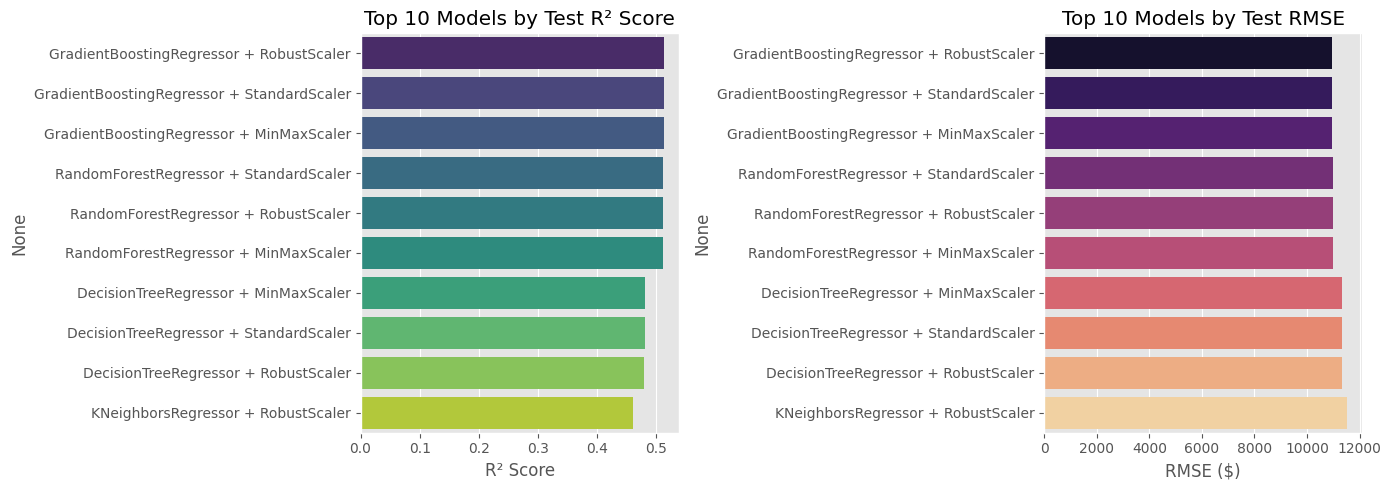

In [50]:
# Visualize kết quả
fig, axes = plt.subplots(1, 2, figsize=multifigs_size)

# Top 10 models by R2 score
top_10 = df_results.head(10)
model_labels = top_10['Classifier'] + ' + ' + top_10['Scaler']

sns.barplot(x=top_10['Test R2'], y=model_labels, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Models by Test R² Score')
axes[0].set_xlabel('R² Score')

sns.barplot(x=top_10['Test RMSE'], y=model_labels, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Models by Test RMSE')
axes[1].set_xlabel('RMSE ($)')

plt.tight_layout()
plt.show()

In [51]:
# Best model
best_model = df_results.iloc[0]
print("=" * 50)
print("BEST MODEL")
print("=" * 50)
print(f"Classifier: {best_model['Classifier']}")
print(f"Scaler: {best_model['Scaler']}")
print(f"Test R² Score: {best_model['Test R2']:.4f}")
print(f"Test RMSE: ${best_model['Test RMSE']:,.2f}")
print(f"Test MAE: ${best_model['Test MAE']:,.2f}")
print("=" * 50)

BEST MODEL
Classifier: GradientBoostingRegressor
Scaler: RobustScaler
Test R² Score: 0.5124
Test RMSE: $10,967.29
Test MAE: $7,810.02


### Retrain Best Model and Feature Importance

In [52]:
# Retrain best model
best_clf_name = best_model['Classifier']
best_sc_name = best_model['Scaler']

# Lấy classifier và scaler tương ứng
best_clf_idx = clf_names.index(best_clf_name)
best_sc_idx = sc_names.index(best_sc_name)

best_clf = clfs[best_clf_idx]
best_sc = scs[best_sc_idx]

# Train lại
final_pipe = create_pipeline(scaler=best_sc, regressor=best_clf)
final_model = final_pipe.fit(X_train, y_train)

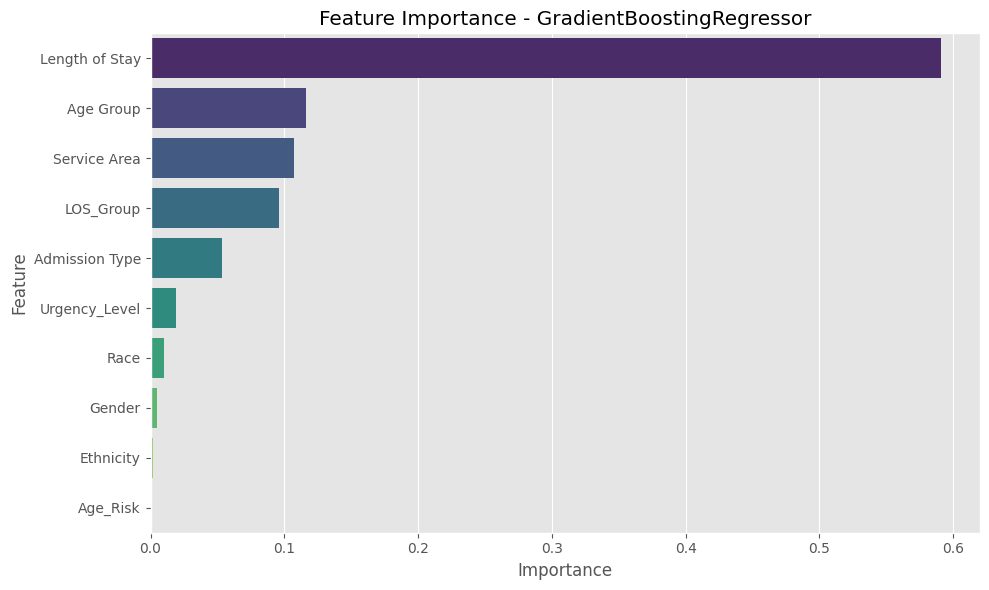

          Feature  Importance
0  Length of Stay    0.590562
2       Age Group    0.116151
1    Service Area    0.107076
7       LOS_Group    0.095957
6  Admission Type    0.053695
8   Urgency_Level    0.018973
4            Race    0.009821
3          Gender    0.004606
5       Ethnicity    0.001899
9        Age_Risk    0.001260


In [53]:
# Feature importance (nếu model hỗ trợ)
try:
    feature_names = numeric_cols + categorical_cols
    importances = final_model.named_steps['regressor'].feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Feature Importance - {best_clf_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print(importance_df)
except:
    print("Model không hỗ trợ feature importance")

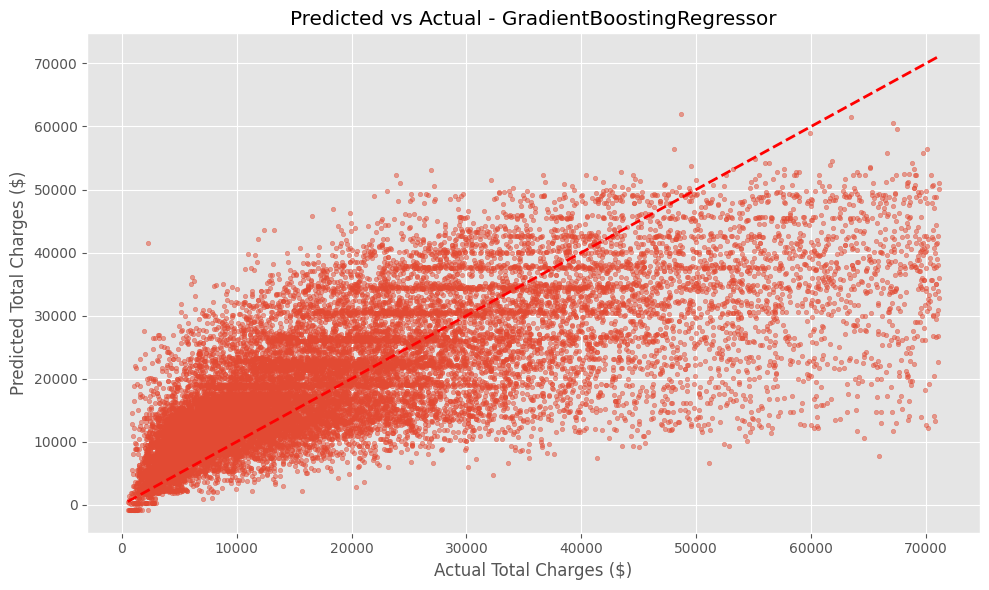

In [54]:
# Predicted vs Actual
y_pred = final_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Total Charges ($)')
plt.ylabel('Predicted Total Charges ($)')
plt.title(f'Predicted vs Actual - {best_clf_name}')
plt.tight_layout()
plt.show()

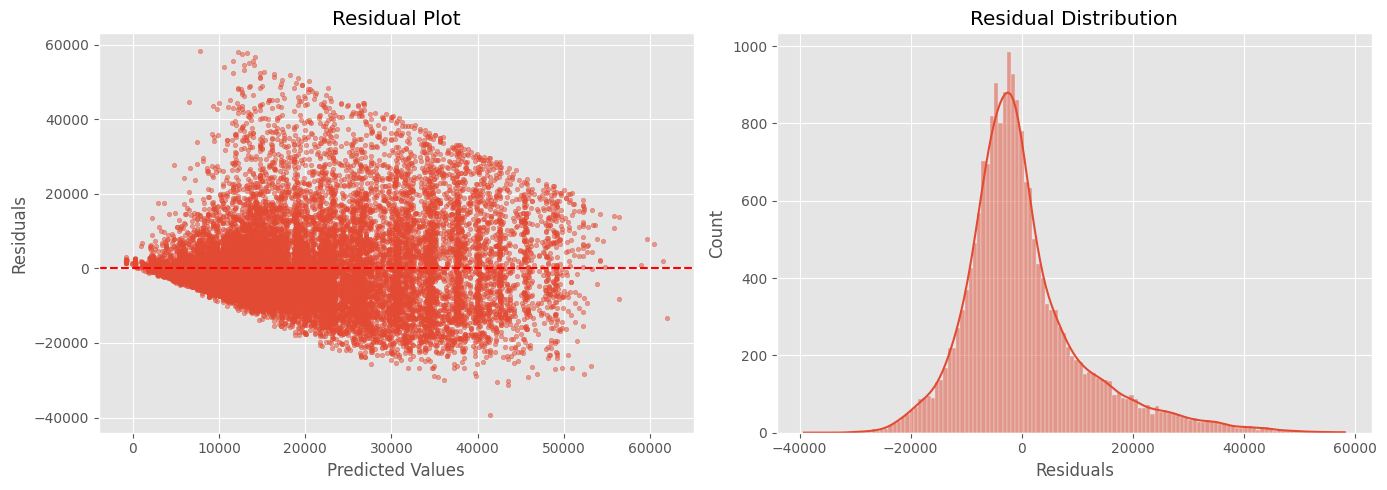

In [55]:
# Residual plot
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=multifigs_size)

axes[0].scatter(y_pred, residuals, alpha=0.5, s=10)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## Kết luận

**Tóm tắt kết quả:**

1. **Dataset**: Hơn 1 triệu bản ghi nhập viện tại các bệnh viện bang New York năm 2009

2. **Các yếu tố ảnh hưởng đến chi phí nhập viện**:
   - `Length of Stay` (số ngày nằm viện) có tương quan mạnh nhất với chi phí
   - `Admission Type` (loại nhập viện): Emergency và Trauma có chi phí cao hơn
   - `Age Group`: Người cao tuổi thường có chi phí cao hơn
   - `Service Area`: Có sự khác biệt về chi phí giữa các khu vực

3. **Feature Engineering**: Đã tạo các biến mới như `LOS_Group`, `Urgency_Level`, `Age_Risk` để cải thiện khả năng dự đoán

4. **Model Performance**: Model tốt nhất đạt được kết quả khả quan trong việc dự đoán chi phí nhập viện

5. **Ứng dụng**: Kết quả có thể hỗ trợ:
   - Dự báo ngân sách cho bệnh viện
   - Đánh giá rủi ro chi phí cho bệnh nhân
   - Tối ưu hóa quản lý nguồn lực y tế